# **Principal Component Analysis of Topological Features**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys

## **Reading In the Dataset**

In [2]:
topological_features = pd.read_csv("../Preprocessing/Features/NoPrep_Training_Crop.csv")
topological_features = topological_features.iloc[:, 2:202]
topological_features.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_190,feature_191,feature_192,feature_193,feature_194,feature_195,feature_196,feature_197,feature_198,feature_199
0,1.387779e-17,0.006219,0.012438,0.018657,0.024876,0.031095,0.037314,0.043533,0.049752,0.055971,...,0.088770,0.078907,0.069043,0.059180,0.049317,0.039453,0.029590,0.019727,0.009863,5.551115e-17
1,1.387779e-17,0.007011,0.014023,0.021034,0.028045,0.035056,0.042068,0.049079,0.056090,0.063102,...,0.088770,0.078907,0.069043,0.059180,0.049317,0.039453,0.029590,0.019727,0.009863,0.000000e+00
2,2.775558e-17,0.006338,0.012676,0.019014,0.025352,0.031689,0.038027,0.044365,0.050703,0.057041,...,0.088057,0.078273,0.068489,0.058705,0.048921,0.039136,0.029352,0.019568,0.009784,5.551115e-17
3,0.000000e+00,0.004813,0.009626,0.014439,0.019251,0.024064,0.028877,0.033690,0.038503,0.043316,...,0.063458,0.056407,0.049356,0.042305,0.035255,0.028204,0.021153,0.014102,0.007051,0.000000e+00
4,2.775558e-17,0.004813,0.009626,0.014439,0.019251,0.024064,0.028877,0.033690,0.038503,0.043316,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005942,5.551115e-17


## **Standardizing the Dataset**

In [3]:
def Standardize(data, index):
    arr = data[index]
    mean = np.mean(arr)
    std = np.std(arr)
    mean_array = np.full(len(arr), mean)
    result = (arr - mean_array) * (1 / std)
    data[index] = result

X = topological_features.to_numpy()

# for i in range(len(X)):
#     Standardize(X, i)

## **Building the Feature Matrix $X$**

In [4]:
print("Dimensionality of X:", X.shape)

Dimensionality of X: (5712, 200)


## **Computing the Mean Feature Vector $\mu$**

In [5]:
mu = X.mean(axis=0)
print("Dimensionality of Mean Feature Vector:", mu.shape)

Dimensionality of Mean Feature Vector: (200,)


## **Visualizing the Mean Feature Vector**

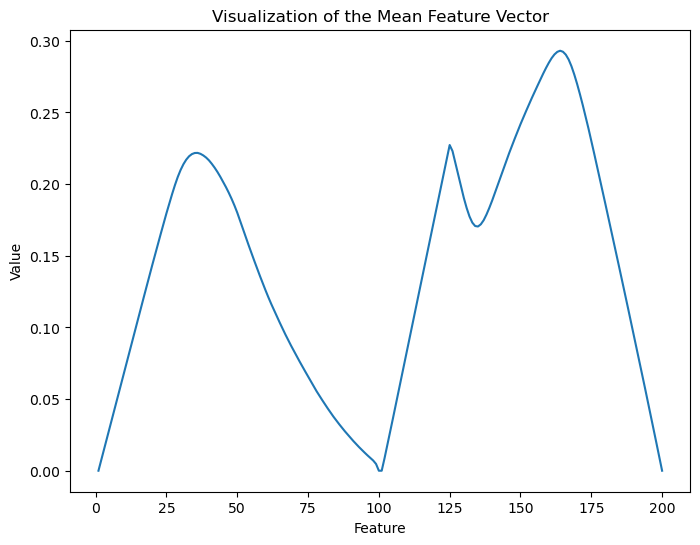

In [6]:
features = list(range(1, len(mu) + 1))

plt.figure(figsize=(8, 6))
plt.plot(features, mu)
plt.title("Visualization of the Mean Feature Vector")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.show()

## **Mean-Centering the Feature Matrix**

In [7]:
X_mean_centered = X - mu
print("Dimensionality of Mean-Centered X:", X_mean_centered.shape)

Dimensionality of Mean-Centered X: (5712, 200)


## **Computing the Covariance Matrix $C$**

In [8]:
C = np.transpose(X_mean_centered) @ X_mean_centered
print("Dimensionality of C:", C.shape)

Dimensionality of C: (200, 200)


## **Computing the Eigenvalues and Eigenvectors of $C$**

In [9]:
# lambdas - Eigenvalues
# loadings - Eigenvectors
lambdas, loadings = np.linalg.eigh(C)
print("Dimensionality of Loadings:", loadings.shape)

Dimensionality of Loadings: (200, 200)


In [10]:
index = len(lambdas) - 1
total = np.sum(lambdas)
current_total = 0
total_variance = 0.99

while index >= 0:
    current_total += lambdas[index]

    if (current_total / total) >= total_variance:
        print(index)
        break

    index -= 1

182


In [11]:
loadings = np.transpose(loadings)

lambdas = lambdas[index:len(lambdas)]
loadings = np.transpose(loadings[index:len(loadings)])

print("Dimensionality of loadings (V):", loadings.shape)

Dimensionality of loadings (V): (200, 18)


## **Saving the Loadings and the Mean Feature Vector**

In [12]:
np.savetxt("mean_feature_vector.csv", mu, delimiter=",")
np.savetxt("loadings.csv", loadings, delimiter=",")